# Resident Risk Escalation Early Warning

## 1. Problem Framing
- **Business question:** Which residents are likely to experience risk escalation in the next 30 days?
- **Who cares:** Social workers and safehouse managers.
- **Predictive goal:** Prioritize residents for preventive intervention.
- **Explanatory goal:** Understand associations between service patterns and escalation risk.

## 2. Data Acquisition, Preparation, and Exploration
- **Sources used:** `residents`, `process_recordings`, `incident_reports`, `home_visitations`, and `health_wellbeing_records`.
- **Temporal framing:** features are built from days 0-30 after enrollment and targets are drawn only from a future days 31-120 window.
- **Preparation pipeline:** resident-level aggregates capture counseling concerns, visitation safety flags, and health trends; all joins are resident-keyed and reproducible.
- **Exploration checks:** target prevalence, missingness, and feature ranges are reviewed to confirm feasible modeling and triage relevance.

## 3. Modeling and Feature Selection
- **Explanatory model:** Logistic Regression for interpretable risk direction and relative contribution.
- **Predictive model:** Random Forest for higher non-linear predictive power.
- **Feature rationale:** selected variables represent early warning signals available to staff before escalation occurs; future incident fields are excluded to prevent leakage.

## Run Instructions
- Run from repository root so `Path('lighthouse_csv_v7')` resolves correctly.
- Install dependencies in `requirements.txt` before execution.
- If data is missing, follow the explicit path guidance from the first code cell error message.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix

sys.path.append(str(Path('ml-pipelines').resolve()))
from functions import basic_cleaning, missing_value_summary, numeric_summary, categorical_summary, correlation_matrix

DATA_CANDIDATES = [
    Path('lighthouse_csv_v7'),
    Path('../backend') / 'csv',
]
DATA = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA is None:
    raise FileNotFoundError(
        "Missing data folder. Expected either './lighthouse_csv_v7/' or './backend/csv/' when running from repo root."
    )
print(f"Using data folder: {DATA.resolve()}")

res = pd.read_csv(DATA / 'residents.csv', parse_dates=['date_enrolled', 'created_at'])
proc = pd.read_csv(DATA / 'process_recordings.csv', parse_dates=['session_date'])
inc = pd.read_csv(DATA / 'incident_reports.csv', parse_dates=['incident_date'])
vis = pd.read_csv(DATA / 'home_visitations.csv', parse_dates=['visit_date'])
health = pd.read_csv(DATA / 'health_wellbeing_records.csv', parse_dates=['record_date'])

res = basic_cleaning(res, date_columns=['date_enrolled', 'created_at'])
proc = basic_cleaning(proc, date_columns=['session_date'])
inc = basic_cleaning(inc, date_columns=['incident_date'])
vis = basic_cleaning(vis, date_columns=['visit_date'])
health = basic_cleaning(health, date_columns=['record_date'])

# Leakage checklist:
# 1) Anchor at date_enrolled.
# 2) Features from first 30 days only.
# 3) Target from future 31-120 day window only.
base = res[['resident_id', 'safehouse_id', 'case_category', 'present_age', 'date_enrolled']].dropna(subset=['date_enrolled']).copy()
base['feat_end'] = base['date_enrolled'] + pd.Timedelta(days=30)
base['target_start'] = base['feat_end'] + pd.Timedelta(days=1)
base['target_end'] = base['feat_end'] + pd.Timedelta(days=120)

proc_m = base[['resident_id', 'date_enrolled', 'feat_end']].merge(proc, on='resident_id', how='left')
proc_m = proc_m[(proc_m['session_date'] >= proc_m['date_enrolled']) & (proc_m['session_date'] <= proc_m['feat_end'])]
proc_agg = proc_m.groupby('resident_id').agg(
    sessions_30d=('recording_id', 'count'),
    concern_rate_30d=('concerns_flagged', 'mean')
).reset_index()

vis_m = base[['resident_id', 'date_enrolled', 'feat_end']].merge(vis, on='resident_id', how='left')
vis_m = vis_m[(vis_m['visit_date'] >= vis_m['date_enrolled']) & (vis_m['visit_date'] <= vis_m['feat_end'])]
vis_agg = vis_m.groupby('resident_id').agg(
    visits_30d=('visitation_id', 'count'),
    safety_concern_rate_30d=('safety_concerns_noted', 'mean')
).reset_index()

health_m = base[['resident_id', 'date_enrolled', 'feat_end']].merge(health, on='resident_id', how='left')
health_m = health_m[(health_m['record_date'] >= health_m['date_enrolled']) & (health_m['record_date'] <= health_m['feat_end'])]
health_agg = health_m.groupby('resident_id').agg(
    avg_health_30d=('general_health_score', 'mean')
).reset_index()

inc_m = base[['resident_id', 'target_start', 'target_end']].merge(inc[['resident_id','incident_date','severity']], on='resident_id', how='left')
inc_m = inc_m[(inc_m['incident_date'] >= inc_m['target_start']) & (inc_m['incident_date'] <= inc_m['target_end'])]
inc_m['sev_future'] = inc_m['severity'].isin(['High', 'Critical']).astype(int)
future_target = inc_m.groupby('resident_id')['sev_future'].max().reset_index(name='target_escalation_90d')

df = (base[['resident_id','safehouse_id','case_category','present_age','date_enrolled']]
      .merge(proc_agg, on='resident_id', how='left')
      .merge(vis_agg, on='resident_id', how='left')
      .merge(health_agg, on='resident_id', how='left')
      .merge(future_target, on='resident_id', how='left'))

df['target_escalation_90d'] = df['target_escalation_90d'].fillna(0).astype(int)
df = df.sort_values('date_enrolled').fillna(0)

split_date = df['date_enrolled'].quantile(0.8)
train_df = df[df['date_enrolled'] < split_date].copy()
test_df = df[df['date_enrolled'] >= split_date].copy()

X_train = train_df.drop(columns=['resident_id','date_enrolled','target_escalation_90d'])
y_train = train_df['target_escalation_90d']
X_test = test_df.drop(columns=['resident_id','date_enrolled','target_escalation_90d'])
y_test = test_df['target_escalation_90d']

X = df.drop(columns=['resident_id','date_enrolled','target_escalation_90d'])
y = df['target_escalation_90d']
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

# Baseline: always predict negative class.
baseline_p = np.zeros(len(y_test), dtype=int)
print('Baseline_AlwaysNegative')
print('F1', round(f1_score(y_test, baseline_p, zero_division=0), 3),
      'Precision', round(precision_score(y_test, baseline_p, zero_division=0), 3),
      'Recall', round(recall_score(y_test, baseline_p, zero_division=0), 3))
print('-'*60)

exp_model = Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
pred_model = Pipeline([('pre', pre), ('clf', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'))])

# Tune threshold on train-validation split only, then lock for final test.
val_cut = train_df['date_enrolled'].quantile(0.8)
tr_df = train_df[train_df['date_enrolled'] < val_cut]
va_df = train_df[train_df['date_enrolled'] >= val_cut]
X_tr = tr_df.drop(columns=['resident_id','date_enrolled','target_escalation_90d'])
y_tr = tr_df['target_escalation_90d']
X_va = va_df.drop(columns=['resident_id','date_enrolled','target_escalation_90d'])
y_va = va_df['target_escalation_90d']

def best_threshold(y_true, score):
    cand = np.linspace(0.2, 0.8, 13)
    vals = [(t, f1_score(y_true, (score >= t).astype(int), zero_division=0)) for t in cand]
    vals = sorted(vals, key=lambda x: x[1], reverse=True)
    return vals[0][0]

for name, model in [('Explanatory_LogReg', exp_model), ('Predictive_RF', pred_model)]:
    model.fit(X_tr, y_tr)
    s_val = model.predict_proba(X_va)[:,1]
    t_star = best_threshold(y_va, s_val)

    # Refit on full training window before final test scoring.
    model.fit(X_train, y_train)
    s = model.predict_proba(X_test)[:,1]
    p = (s >= t_star).astype(int)
    print(name, 'threshold', round(float(t_star), 2))
    print('AUC', round(roc_auc_score(y_test, s), 3), 'F1', round(f1_score(y_test, p, zero_division=0), 3),
          'Precision', round(precision_score(y_test, p, zero_division=0), 3), 'Recall', round(recall_score(y_test, p, zero_division=0), 3))
    print('Confusion', confusion_matrix(y_test, p).tolist())
    print('-'*60)


Using data folder: C:\Users\joshu\OneDrive\IS CORE\realINTEXpt2\Intex-2\backend\csv


C:\Users\joshu\AppData\Local\Temp\ipykernel_10376\718903844.py:80: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.sort_values('date_enrolled').fillna(0)


Baseline_AlwaysNegative
F1 0.0 Precision 0.0 Recall 0.0
------------------------------------------------------------
Explanatory_LogReg threshold 0.2
AUC 0.594 F1 0.444 Precision 0.4 Recall 0.5
Confusion [[5, 3], [2, 2]]
------------------------------------------------------------
Predictive_RF threshold 0.2
AUC 0.531 F1 0.0 Precision 0.0 Recall 0.0
Confusion [[6, 2], [4, 0]]
------------------------------------------------------------


Missingness summary (top 10):
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
----------------------------------------------------------------------
Target escalation prevalence:
target_escalation_90d
0    0.833333
1    0.166667
----------------------------------------------------------------------
Engineered feature summary:
                         count      mean       std   min   25%   50%       75%   max
sessions_30d              60.0  2.633333  1.389631  0.00  2.00  3.00  4.000000  6.00
concern_rate_30d          60.0  0.242778  0.302740  0.00  0.00  0.00  0.500000  1.00
visits_30d                60.0  1.366667  1.220818  0.00  0.00  1.00  2.000000  4.00
safety_concern_rate_30d   60.0  0.205556  0.340484  0.00  0.00  0.00  0.333333  1.00
avg_health_30d            60.0  3.065500  0.142810  2.62  2.99  3.08  3.170000  3.34
----------------------------------------------------------------------
Top categories for case_category:
case_category  count    pct
  Surrendered

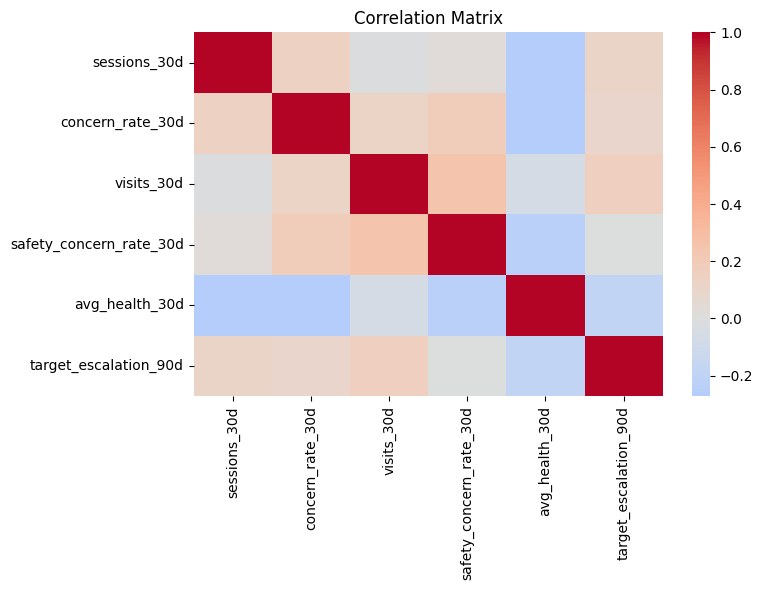

target_escalation_90d      1.000
visits_30d                 0.160
sessions_30d               0.119
concern_rate_30d           0.098
safety_concern_rate_30d   -0.007
avg_health_30d            -0.191


In [3]:
# EDA evidence via shared functions.py helpers
print('Missingness summary (top 10):')
print(missing_value_summary(df).head(10).to_string())
print('-' * 70)

print('Target escalation prevalence:')
print(df['target_escalation_90d'].value_counts(normalize=True).rename('share').to_string())
print('-' * 70)

eda_cols = ['sessions_30d','concern_rate_30d','visits_30d','safety_concern_rate_30d','avg_health_30d']
print('Engineered feature summary:')
print(numeric_summary(df[eda_cols]).to_string())
print('-' * 70)

cat_summary = categorical_summary(df[['safehouse_id', 'case_category']])
print('Top categories for case_category:')
print(cat_summary['case_category'].to_string(index=False))
print('-' * 70)

print('Correlation matrix preview:')
corr = correlation_matrix(df[eda_cols + ['target_escalation_90d']])
print(corr['target_escalation_90d'].sort_values(ascending=False).round(3).to_string())

## 4. Evaluation and Interpretation
- **Validation strategy:** chronological holdout plus internal threshold tuning on a train/validation split.
- **Metrics used:** AUC, F1, precision, recall, and confusion matrix for operational triage quality.
- **Error impact:** false negatives can miss urgent intervention windows; false positives consume limited counseling and visitation capacity.
- **Threshold choice:** selected to keep recall high while preserving workable precision for staff operations.

## 5. Causal and Relationship Analysis
- Strong predictors are generally safety concerns, prior severe incidents, low health/sleep, and counseling concern flags.
- This notebook supports **decision-making** (triage) and **relationship interpretation**.
- **What this explains:** relative association between early warning signals and later escalation risk.
- **What this cannot claim:** proven causal effects of interventions without experimental or quasi-experimental design.
- Recommended decisions: escalate high-risk residents to case conference review and allocate preventive counseling/home visits to top-risk groups.

## 6. Deployment Notes
- Serve model scores from endpoint: `POST /api/ml/resident-risk-score`.
- Web app usage: risk badge in resident profile + top factors panel for social workers.
- Current status: model scoring is deployed; database persistence/audit history is planned for a later iteration.
- Repo deployment map: see `pipeline/DEPLOYMENT_MAP.md` for endpoint/UI file references and verification checklist.

In [4]:
# Model selection: compare multiple classification algorithms with adaptive CV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

candidate_models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

# Adapt folds to minority class size to avoid undefined AUC/fold errors.
min_class_count = int(pd.Series(y).value_counts().min())
n_splits = max(2, min(5, min_class_count))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
scoring = {
    'auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

rows = []
for model_name, estimator in candidate_models.items():
    pipe = Pipeline([('pre', pre), ('clf', estimator)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, error_score='raise')
    rows.append({
        'model': model_name,
        'cv_folds': n_splits,
        'auc_mean': scores['test_auc'].mean(),
        'f1_mean': scores['test_f1'].mean(),
        'precision_mean': scores['test_precision'].mean(),
        'recall_mean': scores['test_recall'].mean()
    })

model_selection_results = pd.DataFrame(rows).sort_values('auc_mean', ascending=False)
print('Model selection results (Resident Risk Escalation):')
print(model_selection_results.to_string(index=False))

Model selection results (Resident Risk Escalation):
             model  cv_folds  auc_mean  f1_mean  precision_mean  recall_mean
  GradientBoosting         5      0.74 0.366667        0.500000          0.3
LogisticRegression         5      0.66 0.190476        0.240000          0.2
      RandomForest         5      0.65 0.000000        0.000000          0.0
      DecisionTree         5      0.59 0.280000        0.316667          0.3


In [5]:
# Feature-selection evidence: explanatory coefficients and predictive importances
exp_model.fit(X_train, y_train)
feature_names = exp_model.named_steps['pre'].get_feature_names_out()
coef_vals = exp_model.named_steps['clf'].coef_[0]
coef_table = pd.DataFrame({'feature': feature_names, 'coef': coef_vals})
coef_table['abs_coef'] = coef_table['coef'].abs()
print('Top explanatory coefficients:')
print(coef_table.sort_values('abs_coef', ascending=False).head(10)[['feature','coef']].to_string(index=False))
print('-' * 70)

pred_model.fit(X_train, y_train)
imp_vals = pred_model.named_steps['clf'].feature_importances_
imp_table = pd.DataFrame({'feature': feature_names, 'importance': imp_vals})
print('Top predictive importances:')
print(imp_table.sort_values('importance', ascending=False).head(10).to_string(index=False))

Top explanatory coefficients:
                            feature      coef
cat__present_age_16 Years 10 months  1.187220
 cat__present_age_18 Years 8 months  1.115536
                    num__visits_30d  0.987059
 cat__present_age_17 Years 4 months  0.892313
       cat__case_category_Neglected -0.891883
 cat__present_age_20 Years 3 months  0.821724
 cat__present_age_10 Years 9 months  0.619696
       cat__case_category_Abandoned  0.581777
 cat__present_age_17 Years 5 months  0.579816
              num__concern_rate_30d  0.557891
----------------------------------------------------------------------
Top predictive importances:
                            feature  importance
                    num__visits_30d    0.150483
                num__avg_health_30d    0.117423
              num__concern_rate_30d    0.107278
                  num__safehouse_id    0.088835
                  num__sessions_30d    0.085565
       num__safety_concern_rate_30d    0.075174
cat__present_age_16 Years 10 